# Prescriptive Analytics - Inventory Optimization

A common challenge that the DVD Rental may face is deciding how many of each genre to stock up on. This is a prescriptive analytics problem that requires some mathematical analysis, specifically optimization using a method of maths known as linear programming. The purpose of this exercise is to give you a basic overview of what goes into solving this problem. From this exercise, you should gain an appreciation for what the field of operations management and management science is about, and how it could relate to your work as a business analyst.

First lets load up some data about the performance of different genres financially.

In [2]:
install.packages("fpc")
install.packages("RMySQL")
install.packages("summarytools")

# Downloading packages -------------------------------------------------------
- Downloading fpc from CRAN ...                 OK [839.7 Kb in 0.36s]
- Downloading mclust from CRAN ...              OK [3.9 Mb in 0.26s]
- Downloading flexmix from CRAN ...             OK [1.7 Mb in 0.21s]
- Downloading prabclus from CRAN ...            OK [470 Kb in 0.4s]
- Downloading diptest from CRAN ...             OK [170.2 Kb in 0.33s]
- Downloading robustbase from CRAN ...          OK [3 Mb in 0.21s]
- Downloading DEoptimR from CRAN ...            OK [72.9 Kb in 0.19s]
- Downloading kernlab from CRAN ...             OK [1.9 Mb in 0.21s]
Successfully downloaded 8 packages in 4 seconds.

The following package(s) will be installed:
- DEoptimR   [1.1-3-1]
- diptest    [0.77-1]
- flexmix    [2.3-20]
- fpc        [2.2-13]
- kernlab    [0.9-33]
- mclust     [6.1.1]
- prabclus   [2.3-4]
- robustbase [0.99-4-1]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-g

In [ ]:
library(ggplot2)
library(fpc)
library(tidyverse)
library(rpart)
library(rpart.plot)

mm <- src_mysql(
  host='[updateme]',
  port=3306,
  user='admin',
  password='[updateme]',
  dbname='dvdrental'
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“`src_mysql()` was deprecated in dplyr 1.0.0.
ℹ Please use `tbl()` directly with a database connection”


In [4]:
# Write out a query and retrieve that table from the database
query <- "SELECT 
    f.title AS film_name,
    COUNT(distinct i.inventory_id) AS number_of_copies,
    COUNT(distinct r.rental_id) AS number_of_rentals
	FROM dvdrental.film f
	LEFT JOIN dvdrental.inventory i ON f.film_id = i.film_id
	LEFT JOIN dvdrental.rental r ON i.inventory_id = r.inventory_id
	GROUP BY f.title
	ORDER BY number_of_copies DESC, number_of_rentals DESC, f.title"

df1 <- tbl(mm, sql(query)) %>% collect() # Get data from the database
print(df1)

# A tibble: 1,000 × 3
   film_name           number_of_copies number_of_rentals
   <chr>                          <dbl>             <dbl>
 1 Bucket Brotherhood                 8                34
 2 Rocketeer Mother                   8                33
 3 Forward Temple                     8                32
 4 Grit Clockwork                     8                32
 5 Juggler Hardly                     8                32
 6 Ridgemont Submarine                8                32
 7 Scalawag Duck                      8                32
 8 Apache Divine                      8                31
 9 Goodfellas Salute                  8                31
10 Hobbit Alien                       8                31
# ℹ 990 more rows


In [26]:
# Write out a query to calculate the average replacement cost, average lifetime revenue, and average profit of a movie in each genre
query_genre_stats <- "
SELECT 
    c.name AS genre,
	COUNT(DISTINCT f.title) as num_movies,
    AVG(f.replacement_cost) AS avg_replacement_cost,
    SUM(p.amount) AS total_lifetime_revenue,
	COUNT(r.rental_id) AS num_rentals
FROM dvdrental.film f
JOIN dvdrental.film_category fc ON f.film_id = fc.film_id
JOIN dvdrental.category c ON fc.category_id = c.category_id
LEFT JOIN dvdrental.inventory i ON f.film_id = i.film_id
LEFT JOIN dvdrental.rental r ON i.inventory_id = r.inventory_id
LEFT JOIN dvdrental.payment p ON r.rental_id = p.rental_id
GROUP BY c.name
ORDER BY c.name
"

df_genre_stats <- tbl(mm, sql(query_genre_stats)) %>% collect() # Get data from the database
df_genre_stats

Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 2 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 3 imported as numeric”
Warning message in dbSendQuery(con, sql):
“Decimal MySQL column 2 imported as numeric”
Warning message in dbSendQuery(con, sql):
“Decimal MySQL column 3 imported as numeric”


genre,num_movies,avg_replacement_cost,total_lifetime_revenue,num_rentals
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Action,64,21.1839,3962,1112
Animation,66,20.2928,4256,1166
Children,60,20.0676,3318,945
Classics,57,20.9544,3362,939
Comedy,58,19.0350,4011,941
Documentary,68,20.7140,3759,1050
Drama,62,21.6381,4128,1060
Family,69,20.0173,3840,1096
Foreign,73,18.6121,3944,1033


In [27]:
# Calculate average revenue per rental for each genre
df_genre_stats <- df_genre_stats %>%
  mutate(avg_revenue_per_rental = total_lifetime_revenue / num_rentals)

df_genre_stats

genre,num_movies,avg_replacement_cost,total_lifetime_revenue,num_rentals,avg_revenue_per_rental
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Action,64,21.1839,3962,1112,3.562950
Animation,66,20.2928,4256,1166,3.650086
Children,60,20.0676,3318,945,3.511111
Classics,57,20.9544,3362,939,3.580405
Comedy,58,19.0350,4011,941,4.262487
Documentary,68,20.7140,3759,1050,3.580000
Drama,62,21.6381,4128,1060,3.894340
Family,69,20.0173,3840,1096,3.503650
Foreign,73,18.6121,3944,1033,3.818006


In [29]:
# Sort df_genre_stats by the last column (avg_revenue_per_rental)
df_genre_stats <- df_genre_stats %>%
  arrange(desc(avg_revenue_per_rental))

head(df_genre_stats)

genre,num_movies,avg_replacement_cost,total_lifetime_revenue,num_rentals,avg_revenue_per_rental
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Comedy,58,19.0350,4011,941,4.262487
New,63,19.7096,3975,944,4.210805
Sports,74,20.5746,4903,1179,4.158609
Games,61,20.7428,3931,969,4.056760
Horror,56,19.6207,3409,846,4.029551
Sci-Fi,61,21.1868,4346,1101,3.947321


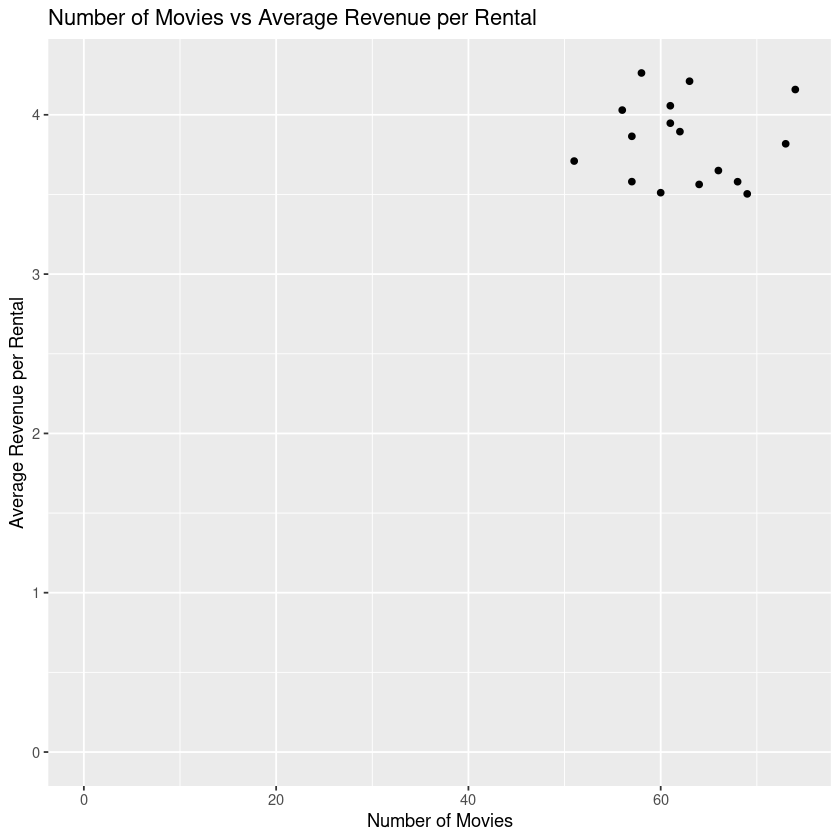

In [32]:
# Load necessary library for plotting
library(ggplot2)

# Create a scatter plot of num_movies vs avg_revenue_per_rental starting at origin
ggplot(df_genre_stats, aes(x = num_movies, y = avg_revenue_per_rental)) +
  geom_point() +
  labs(title = "Number of Movies vs Average Revenue per Rental",
       x = "Number of Movies",
       y = "Average Revenue per Rental") +
  xlim(0, NA) +
  ylim(0, NA)

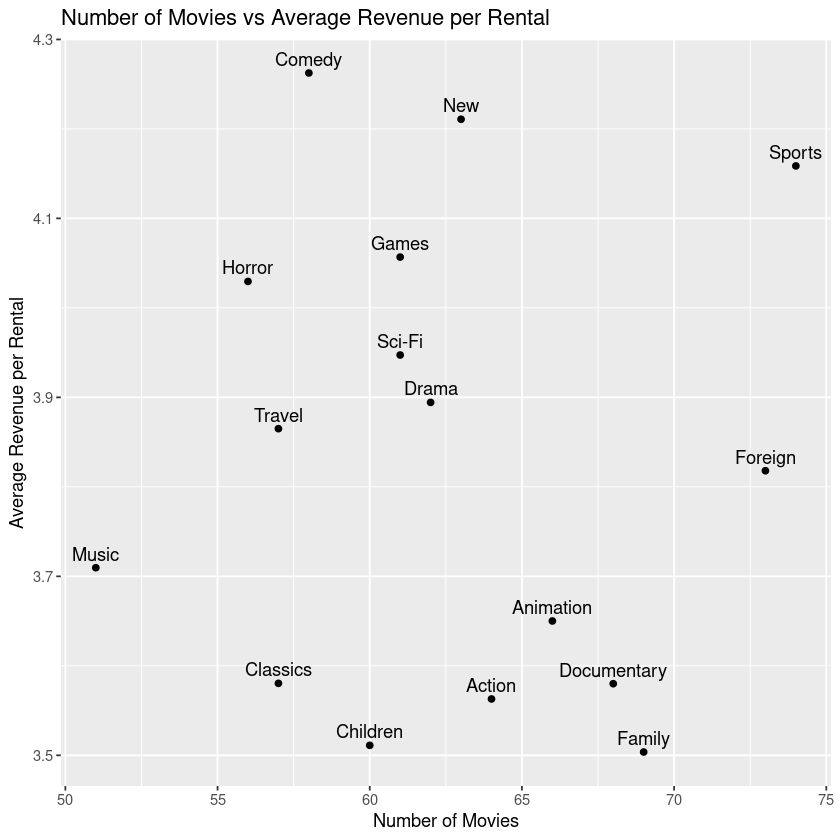

In [34]:
# Load necessary library for plotting
library(ggplot2)

# Create a scatter plot of num_movies vs avg_revenue_per_rental starting at origin
# and label the points with genre names
ggplot(df_genre_stats, aes(x = num_movies, y = avg_revenue_per_rental, label = genre)) +
  geom_point() +
  geom_text(vjust = -0.5, hjust = 0.5) +
  labs(title = "Number of Movies vs Average Revenue per Rental",
       x = "Number of Movies",
       y = "Average Revenue per Rental")

So this shows us that we are definitely not stocking optimally for our revenue profile. We want to see more movies in stock that have high revenue for the company. Next lets try to figure out what the optimal number of movies of each genre should be based on their revenue potential.

Note that this is a more complicated problem to solve quantitatively than it might appear at first. You will see how being data driven requires a lot of thinking and evaluation from multiple different perspectives of the organization.

## Deciding what to optimize with stocking decisions

First lets get a sense of which numbers are related to each other using a correlation table.

In [36]:
# Calculate the correlation matrix for all numerical variables in df_genre_stats
correlation_matrix <- cor(df_genre_stats[, sapply(df_genre_stats, is.numeric)])

# Display the correlation matrix
correlation_matrix

,num_movies,avg_replacement_cost,total_lifetime_revenue,num_rentals,avg_revenue_per_rental
num_movies,1.00000000,0.1225412,0.7055697,0.7925865,-0.04555477
avg_replacement_cost,0.12254116,1.0000000,0.3805161,0.5344279,-0.21489181
total_lifetime_revenue,0.70556973,0.3805161,1.0000000,0.8367661,0.41141033
num_rentals,0.79258653,0.5344279,0.8367661,1.0000000,-0.15213846
avg_revenue_per_rental,-0.04555477,-0.2148918,0.4114103,-0.1521385,1.00000000


We can see that average revenue per rental is not really correlated with the lifetime revenue or number of rentals, while life time revenue is strongly correlated with number of rentals. This means that choosing to optimize one of these may lead to a trade off with the other. Note that you can combine multiple different factors in an optimization problem as well, which makes it more complex - but I want us to start with a pretty straightforward example where we are optimizing on one thing primarily.

### I want to optimize on Average Revenue Per Rental i.e. I want more of movie genres that make me more revenue on average.

Lets say we have a budget of $10,000 to buy more movies. With just this information, lets perform some optimization.

In [38]:
df_genre_stats[c("genre","avg_revenue_per_rental")]

genre,avg_revenue_per_rental
<chr>,<dbl>
Comedy,4.262487
New,4.210805
Sports,4.158609
Games,4.056760
Horror,4.029551
Sci-Fi,3.947321
Drama,3.894340
Travel,3.864994
Foreign,3.818006


In [23]:
#installing the package for linear programming

install.packages("lpSolve")

# Downloading packages -------------------------------------------------------
- Downloading lpSolve from CRAN ...             OK [365.3 Kb in 0.19s]
Successfully downloaded 1 package in 0.3 seconds.

The following package(s) will be installed:
- lpSolve [5.6.23]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing lpSolve ...                        OK [installed binary and cached in 0.68s]


In [44]:
# Load necessary library
library(lpSolve)

# Define the budget
budget <- 10000

# Extract the average replacement cost and average revenue per rental for each genre
avg_replacement_cost <- df_genre_stats$avg_replacement_cost
avg_revenue <- df_genre_stats$avg_revenue_per_rental

# Define the objective function (maximize the average revenue per rental)
objective <- avg_revenue

# Define the constraint matrix (only one constraint: total cost should be within the budget)
constraint_matrix <- matrix(avg_replacement_cost, nrow = 1)

# Define the right-hand side of the constraint (the budget)
rhs <- budget

# Define the direction of the constraint (less than or equal to the budget)
direction <- "<="

# Solve the linear programming problem
solution <- lp("max", objective, constraint_matrix, direction, rhs, all.int = TRUE)

# Get the number of movies to stock for each genre
num_movies_to_stock <- solution$solution

# Add the result to the dataframe
df_genre_stats$num_movies_to_stock <- num_movies_to_stock

df_genre_stats[c("genre","num_movies_to_stock","avg_replacement_cost","avg_revenue_per_rental")]

genre,num_movies_to_stock,avg_replacement_cost,avg_revenue_per_rental
<chr>,<dbl>,<dbl>,<dbl>
Comedy,525,19.0350,4.262487
New,0,19.7096,4.210805
Sports,0,20.5746,4.158609
Games,0,20.7428,4.056760
Horror,0,19.6207,4.029551
Sci-Fi,0,21.1868,3.947321
Drama,0,21.6381,3.894340
Travel,0,19.1463,3.864994
Foreign,0,18.6121,3.818006


Can you try to understand what your solution is recommending? Can you think of why? 

Review the simple case for two options (series vs movie) in the graphic below before proceeding.



![image](image.png)


This is one of the rare instances where I will be sending you back to a simpler tool like Excel for the next steps! See the Excel file uploaded to the assignment area. (Called DVD Rental Optimization)

Using the Solver Add In Excel, and the ability to SEE your data makes it much easier to solve this optimization problem for those without a mathematical backgroud!

Optimization involves a lot of iteration as well as trial and error, so document every step in the process and the source of your rationale for each individual step

[DOWNLOAD EXCEL FILE]

When you finish working through the Excel file, come back here and move the dvd rental data into Excel and complete the problem. If you are feeling very bold, try and use the AI Assistant to solve the problem all within Datalab using R. Keep in mind what constraints you want to include and provide that to the AI Assistant.